## Import Libraries

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import KBinsDiscretizer, Binarizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

sns.set(style='whitegrid')

## Load Dataset


In [47]:
df=sns.load_dataset('titanic')

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [49]:
# Select useful numerical columns
df = df[['age', 'fare', 'survived']].dropna()

df.sample(3)


,age,fare,survived
513,54.0,59.4000,1
571,53.0,51.4792,1
265,36.0,10.5000,0


In [50]:
df.shape

(714, 3)

## 3. Visualize Original Data


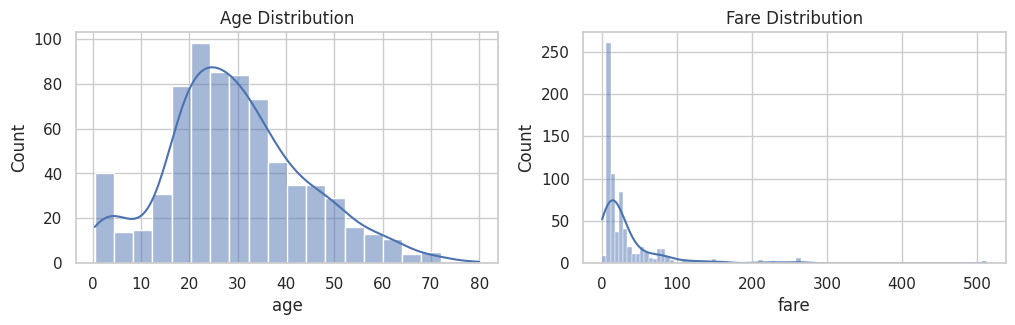

In [51]:
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.histplot(df['fare'], kde=True)
plt.title("Fare Distribution")
plt.show()

# Train Test Split


In [52]:
X=df[['age', 'fare']]
y=df['survived']
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

## Equal Width (Uniform) Binning

In [53]:
uniform_binner=KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
X_train_uniform=uniform_binner.fit_transform(X_train)
X_test_uniform=uniform_binner.fit_transform(X_test)
print("\nUniform Binning Sample:")
print(X_train_uniform[:5])



Uniform Binning Sample:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [2. 0.]
 [1. 0.]]


## Quantile (Equal Frequency) Binning

In [54]:
quantile_binner = KBinsDiscretizer(
    n_bins=5, encode='ordinal', strategy='quantile'
)

X_train_quantile = quantile_binner.fit_transform(X_train)
X_test_quantile = quantile_binner.transform(X_test)

print("\nQuantile Binning Sample:")
print(X_train_quantile[:5])



Quantile Binning Sample:
[[2. 2.]
 [2. 2.]
 [2. 2.]
 [3. 0.]
 [2. 2.]]


## K-Means Binning

In [55]:
kmeans_binner = KBinsDiscretizer(
    n_bins=5, encode='ordinal', strategy='kmeans'
)

X_train_kmeans = kmeans_binner.fit_transform(X_train)
X_test_kmeans = kmeans_binner.transform(X_test)

print("\nKMeans Binning Sample:")
print(X_train_kmeans[:5])


KMeans Binning Sample:
[[2. 0.]
 [1. 0.]
 [2. 0.]
 [2. 0.]
 [1. 0.]]


## Decision Tree Binning (Supervised)

In [56]:
tree = DecisionTreeClassifier(max_leaf_nodes=5)

# Fit tree on ONE feature (fare)
tree.fit(X_train[['fare']], y_train)

# Create bins based on leaf nodes
X_train_tree_bins = tree.apply(X_train[['fare']])
X_test_tree_bins = tree.apply(X_test[['fare']])

print("\nDecision Tree Binning Sample:")
print(X_train_tree_bins[:5])


Decision Tree Binning Sample:
[8 8 8 3 8]


## Custom / Domain-Based Binning

In [57]:
# Example: Fare categories
def fare_bins(x):
    if x < 10:
        return "Low"
    elif x < 50:
        return "Medium"
    else:
        return "High"

df['fare_custom_bin'] = df['fare'].apply(fare_bins)

print("\nCustom Binning Sample:")
print(df[['fare', 'fare_custom_bin']].head())


Custom Binning Sample:
      fare fare_custom_bin
0   7.2500             Low
1  71.2833            High
2   7.9250             Low
3  53.1000            High
4   8.0500             Low


## Binarisation

In [58]:
binarizer = Binarizer(threshold=50)

fare_binary_train = binarizer.fit_transform(X_train[['fare']])
fare_binary_test = binarizer.transform(X_test[['fare']])

print("\nBinarisation Sample:")
print(fare_binary_train[:5])


Binarisation Sample:
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]]


## Visualization (Before vs After)

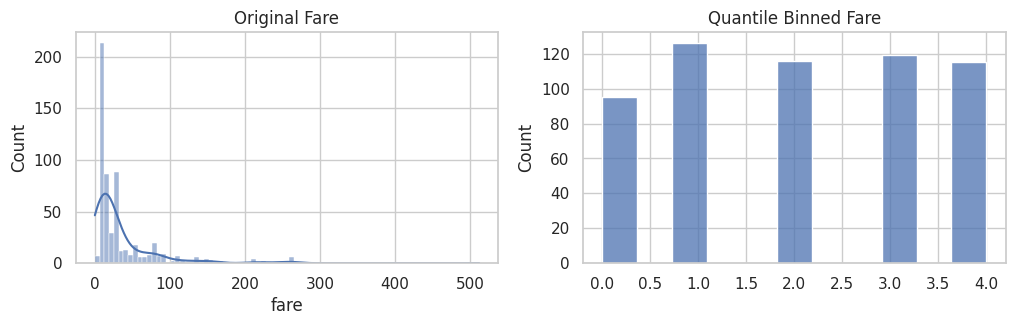

In [60]:
plt.figure(figsize=(12,3))

plt.subplot(1,2,1)
sns.histplot(X_train['fare'], kde=True)
plt.title("Original Fare")

plt.subplot(1,2,2)
sns.histplot(X_train_quantile[:,1], kde=False)
plt.title("Quantile Binned Fare")

plt.show()
